In [12]:
# =====================
# 1. IMPORTS
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)


In [13]:

# =====================
# 2. LOAD DATA
# =====================
df = pd.read_csv('clinical_pneumonia_dataset.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (1500, 12)
  patient_id   timestamp  note_sequence  \
0   PNE-6733  2022-06-11              0   
1   PNE-6733  2022-06-12              1   
2   PNE-6733  2022-06-13              2   
3   PNE-6733  2022-06-14              3   
4   PNE-6733  2022-06-15              4   

                                       clinical_note  fever  tachycardia  \
0  Pyrexia. rapid heart rate. rales. hypoxemia. p...      1            1   
1  Fever. tachycardia. rales. spo2 < 94%. product...      1            1   
2  Raised body temp. tachycardia. crackles. spo2 ...      1            1   
3  Rapid heart rate. rales. low oxygen saturation...      0            1   
4  Febrile. rapid heart rate. crackles. low oxyge...      1            1   

   crackles  oxygen_saturation  wbc_count chest_xray_result true_label  \
0         1          93.500000   7.500000     consolidation  pneumonia   
1         1          93.500000   7.500000     consolidation  pneumonia   
2         1          93.500000   7.500000   

In [14]:

# =====================
# 3. DROP UNNECESSARY COLUMNS
# =====================
df = df.drop(columns=['patient_id', 'timestamp', 'note_sequence',
                       'clinical_note', 'uncertainty_score'])


In [15]:

# =====================
# 4. BINARY TARGET — Pneumonia vs Not Pneumonia
# =====================
df['true_label'] = df['true_label'].apply(lambda x: 1 if x == 'pneumonia' else 0)

print("\nTarget Distribution:")
print(df['true_label'].value_counts())
print("0 = Not Pneumonia, 1 = Pneumonia")



Target Distribution:
true_label
0    1000
1     500
Name: count, dtype: int64
0 = Not Pneumonia, 1 = Pneumonia


C:\Users\Ved Barthwal\AppData\Local\Temp\ipykernel_29996\2301535013.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='true_label', data=df, palette='Set2')


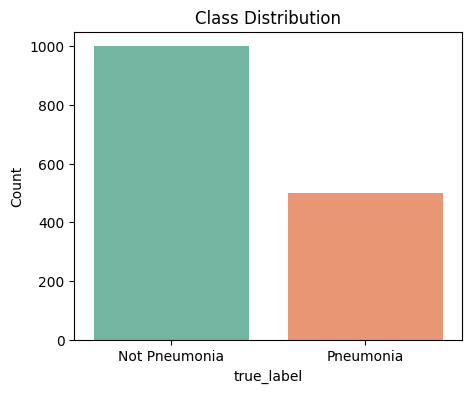

C:\Users\Ved Barthwal\AppData\Local\Temp\ipykernel_29996\2301535013.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='true_label', y='oxygen_saturation', data=df, palette='Set3')


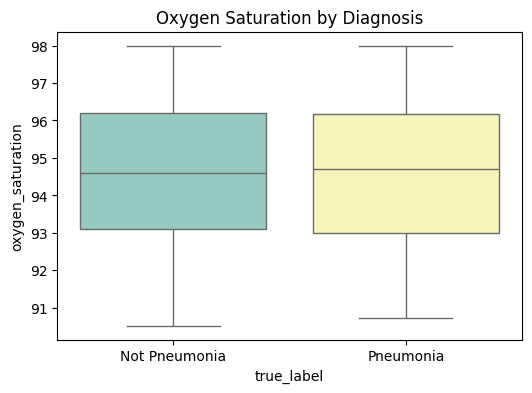

C:\Users\Ved Barthwal\AppData\Local\Temp\ipykernel_29996\2301535013.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='true_label', y='wbc_count', data=df, palette='pastel')


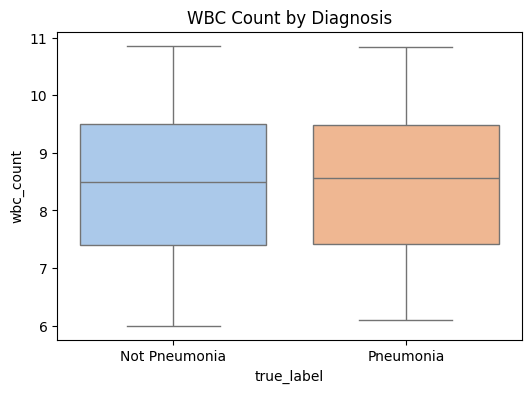

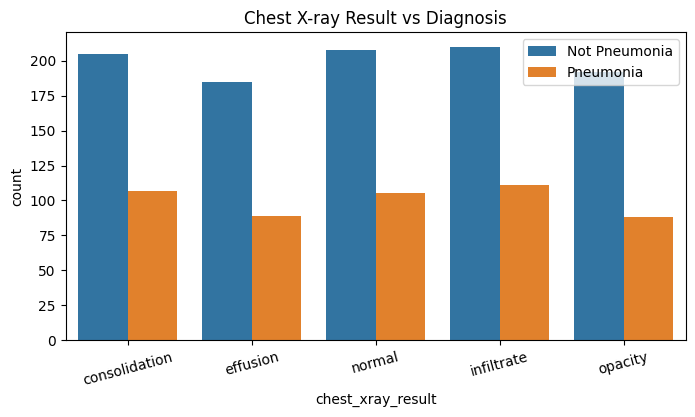

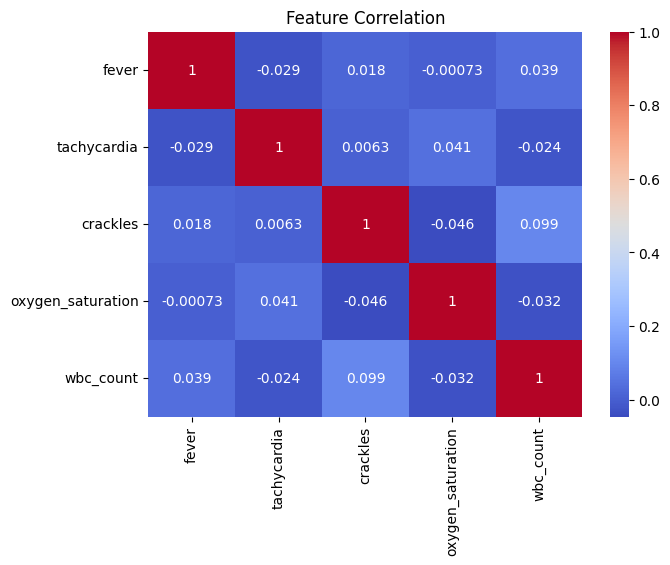

In [16]:

# =====================
# 5. EDA
# =====================

# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='true_label', data=df, palette='Set2')
plt.xticks([0,1], ['Not Pneumonia', 'Pneumonia'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

# Oxygen saturation by diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='true_label', y='oxygen_saturation', data=df, palette='Set3')
plt.xticks([0,1], ['Not Pneumonia', 'Pneumonia'])
plt.title('Oxygen Saturation by Diagnosis')
plt.show()

# WBC count by diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='true_label', y='wbc_count', data=df, palette='pastel')
plt.xticks([0,1], ['Not Pneumonia', 'Pneumonia'])
plt.title('WBC Count by Diagnosis')
plt.show()

# Chest X-ray result vs diagnosis
plt.figure(figsize=(8,4))
sns.countplot(x='chest_xray_result', hue='true_label', data=df)
plt.title('Chest X-ray Result vs Diagnosis')
plt.xticks(rotation=15)
plt.legend(['Not Pneumonia', 'Pneumonia'])
plt.show()

# Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[['fever','tachycardia','crackles',
                'oxygen_saturation','wbc_count']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


In [17]:

# =====================
# 6. PREPROCESSING
# =====================

# One-hot encode chest_xray_result
df = pd.get_dummies(df, columns=['chest_xray_result'])

# Features and Target
X = df.drop('true_label', axis=1)
y = df['true_label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [18]:

# =====================
# 7. TRAIN MODELS
# =====================

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)



===== Logistic Regression =====
Accuracy: 57.67%

Classification Report:
               precision    recall  f1-score   support

Not Pneumonia       0.78      0.51      0.61       200
    Pneumonia       0.42      0.72      0.53       100

     accuracy                           0.58       300
    macro avg       0.60      0.61      0.57       300
 weighted avg       0.66      0.58      0.59       300



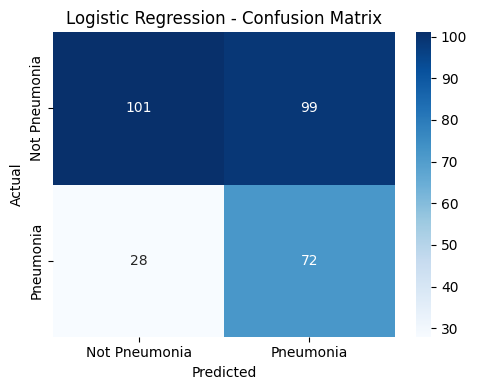


===== Random Forest =====
Accuracy: 72.00%

Classification Report:
               precision    recall  f1-score   support

Not Pneumonia       0.77      0.83      0.80       200
    Pneumonia       0.60      0.50      0.54       100

     accuracy                           0.72       300
    macro avg       0.68      0.67      0.67       300
 weighted avg       0.71      0.72      0.71       300



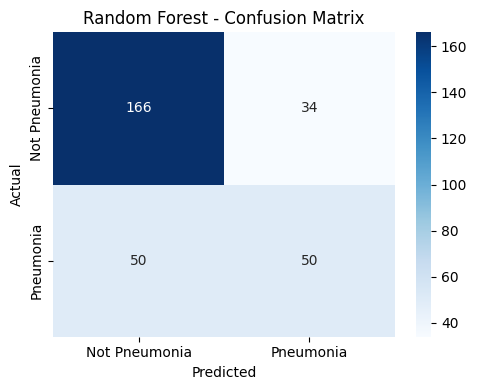


===== Gradient Boosting =====
Accuracy: 73.00%

Classification Report:
               precision    recall  f1-score   support

Not Pneumonia       0.76      0.86      0.81       200
    Pneumonia       0.63      0.47      0.54       100

     accuracy                           0.73       300
    macro avg       0.70      0.67      0.67       300
 weighted avg       0.72      0.73      0.72       300



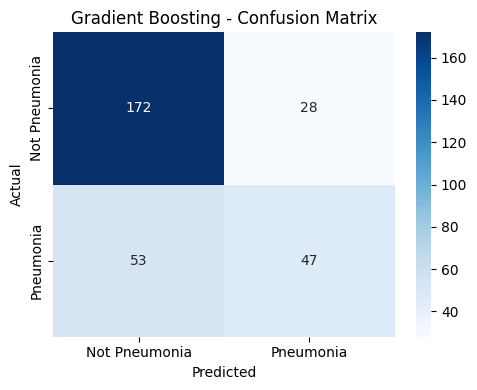

In [19]:

# =====================
# 8. EVALUATE MODELS
# =====================

def evaluate(name, y_test, preds):
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, preds,
                                target_names=['Not Pneumonia', 'Pneumonia']))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Pneumonia', 'Pneumonia'],
                yticklabels=['Not Pneumonia', 'Pneumonia'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

evaluate("Logistic Regression",   y_test, lr_preds)
evaluate("Random Forest",         y_test, rf_preds)
evaluate("Gradient Boosting",     y_test, gb_preds)



In [20]:

# =====================
# 9. CROSS VALIDATION
# =====================
print("\n===== Cross Validation (5-fold) =====")
for name, model in [("Logistic Regression", lr),
                     ("Random Forest", rf),
                     ("Gradient Boosting", gb)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='recall')
    print(f"{name} Recall: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")




===== Cross Validation (5-fold) =====
Logistic Regression Recall: 73.60% ± 4.41%
Random Forest Recall: 31.20% ± 6.97%
Gradient Boosting Recall: 29.20% ± 6.79%


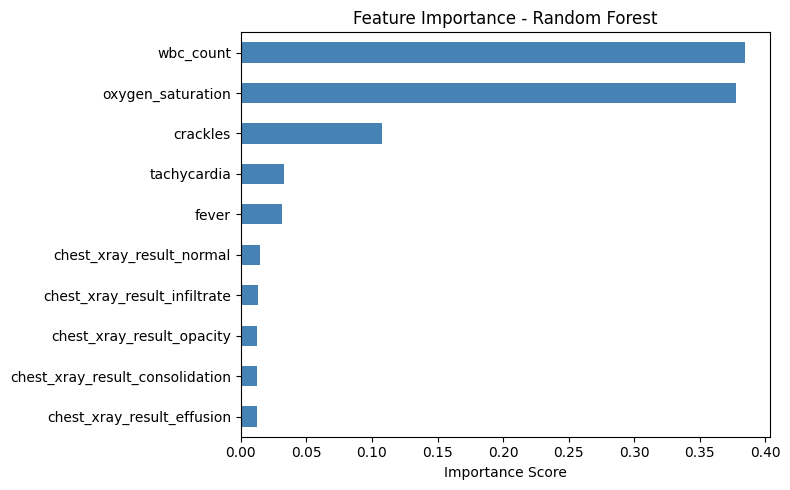

In [21]:
# =====================
# 10. FEATURE IMPORTANCE
# =====================
feat_names = X.columns.tolist()
feat_imp = pd.Series(rf.feature_importances_, index=feat_names)
feat_imp.sort_values().plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [23]:

# =====================
# 11. PREDICT A NEW PATIENT
# =====================
# Example: new patient data
new_patient = pd.DataFrame([{
    'fever': 1,
    'tachycardia': 1,
    'crackles': 1,
    'oxygen_saturation': 91.0,
    'wbc_count': 13.5,
    'chest_xray_result_consolidation': 1,
    'chest_xray_result_effusion': 0,
    'chest_xray_result_infiltrate': 0,
    'chest_xray_result_normal': 0,
    'chest_xray_result_opacity': 0
}])

new_patient_scaled = scaler.transform(new_patient)
prediction = rf.predict(new_patient_scaled)
probability = rf.predict_proba(new_patient_scaled)[0][1]

print(f"\nPrediction: {'PNEUMONIA' if prediction[0] == 1 else 'NOT PNEUMONIA'}")
print(f"Pneumonia Probability: {probability*100:.1f}%")


Prediction: NOT PNEUMONIA
Pneumonia Probability: 37.5%


Testing different thresholds:

Threshold 0.5 → Accuracy: 73.0%  |  Pneumonia Recall: 47.0%
Threshold 0.4 → Accuracy: 73.0%  |  Pneumonia Recall: 63.0%
Threshold 0.35 → Accuracy: 71.0%  |  Pneumonia Recall: 71.0%
Threshold 0.3 → Accuracy: 67.7%  |  Pneumonia Recall: 80.0%
Threshold 0.25 → Accuracy: 64.3%  |  Pneumonia Recall: 86.0%

===== FINAL MODEL (GB + Threshold 0.35) =====
Accuracy        : 71.0%
Pneumonia Recall: 71.0%
               precision    recall  f1-score   support

Not Pneumonia       0.83      0.71      0.77       200
    Pneumonia       0.55      0.71      0.62       100

     accuracy                           0.71       300
    macro avg       0.69      0.71      0.69       300
 weighted avg       0.74      0.71      0.72       300



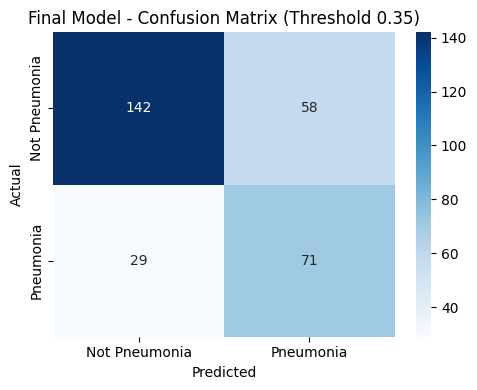

--- High Risk Patient ---

Pneumonia Probability : 84.8%
Prediction            : 🔴 PNEUMONIA

--- Low Risk Patient ---

Pneumonia Probability : 56.7%
Prediction            : 🔴 PNEUMONIA


In [25]:
# =====================
# ADDITION — THRESHOLD TUNING & FINAL MODEL
# =====================
from sklearn.metrics import recall_score

# Step 1 — Find best threshold
gb_probs = gb.predict_proba(X_test)[:, 1]

print("Testing different thresholds:\n")
for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    preds = (gb_probs >= threshold).astype(int)
    acc = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds)
    print(f"Threshold {threshold} → Accuracy: {acc*100:.1f}%  |  Pneumonia Recall: {recall*100:.1f}%")

# Step 2 — Use best threshold (0.35)
final_preds = (gb_probs >= 0.35).astype(int)

print("\n===== FINAL MODEL (GB + Threshold 0.35) =====")
print(f"Accuracy        : {accuracy_score(y_test, final_preds)*100:.1f}%")
print(f"Pneumonia Recall: {recall_score(y_test, final_preds)*100:.1f}%")
print(classification_report(y_test, final_preds,
      target_names=['Not Pneumonia', 'Pneumonia']))

# Step 3 — Final Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Pneumonia', 'Pneumonia'],
            yticklabels=['Not Pneumonia', 'Pneumonia'])
plt.title('Final Model - Confusion Matrix (Threshold 0.35)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# =====================
# ADDITION — PREDICT NEW PATIENT
# =====================
def predict_patient(fever, tachycardia, crackles,
                    oxygen_saturation, wbc_count, xray_result):
    
    patient = pd.DataFrame([{
        'fever'                            : fever,
        'tachycardia'                      : tachycardia,
        'crackles'                         : crackles,
        'oxygen_saturation'                : oxygen_saturation,
        'wbc_count'                        : wbc_count,
        'chest_xray_result_consolidation'  : 1 if xray_result == 'consolidation' else 0,
        'chest_xray_result_effusion'       : 1 if xray_result == 'effusion'      else 0,
        'chest_xray_result_infiltrate'     : 1 if xray_result == 'infiltrate'    else 0,
        'chest_xray_result_normal'         : 1 if xray_result == 'normal'        else 0,
        'chest_xray_result_opacity'        : 1 if xray_result == 'opacity'       else 0,
    }])

    patient_scaled = scaler.transform(patient)
    prob = gb.predict_proba(patient_scaled)[0][1]
    result = '🔴 PNEUMONIA' if prob >= 0.35 else '🟢 NOT PNEUMONIA'

    print(f"\nPneumonia Probability : {prob*100:.1f}%")
    print(f"Prediction            : {result}")

# =====================
# TEST WITH EXAMPLE PATIENTS
# =====================

# High risk patient
print("--- High Risk Patient ---")
predict_patient(
    fever=1,
    tachycardia=1,
    crackles=1,
    oxygen_saturation=91.0,
    wbc_count=13.5,
    xray_result='consolidation'
)

# Low risk patient
print("\n--- Low Risk Patient ---")
predict_patient(
    fever=0,
    tachycardia=0,
    crackles=0,
    oxygen_saturation=98.0,
    wbc_count=7.0,
    xray_result='normal'
)

In [26]:
## https://claude.ai/share/306ed458-3ae3-4d47-befe-484d220dd68d

In [ ]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))